In [1]:
from MS9710C import AnritsuOSA
from TBS1102B import TektronixDO
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
def gaussian(x, A, mu, fwhm):
    return A * np.exp(-4*np.log(2)*(x - mu)**2 / fwhm**2)

In [3]:
try:
    osa = AnritsuOSA()
    osa.get_trace()
    osa.cleanup()
    print("Loaded data from instruments")
except Exception as e:
    print("Instrument read failed:", e)
    osa_data = np.loadtxt("spectra.txt")
    osa.wlArray, osa.trace = osa_data[:,0], osa_data[:,1]
    print("Loaded data from text file")
try:
    dso = TektronixDO()
    dso.get_trace()
    dso.cleanup()
    print("Loaded data from instruments")
except Exception as e:
    print("Instrument read failed:", e)
    # Load fallback data from file
    dso_data = np.loadtxt("ac.txt")
    dso.time, dso.trace = dso_data[:,0], dso_data[:,1]
    print("Loaded data from text file")

Instrument read failed: Instrument not found
Loaded data from text file
Instrument read failed: Instrument not found
Loaded data from text file


In [60]:
# Spectral data
wl_at_max = np.mean(osa.wlArray[osa.trace==np.max(osa.trace)])
wl = osa.wlArray
wl_window = 40
wl_croped = wl[((wl_at_max + wl_window) > wl) & ((wl_at_max - wl_window) < wl)]
osa_trace = (osa.trace-np.min(osa.trace))/(np.max(osa.trace)-np.min(osa.trace))
osa_trace_croped = osa_trace[((wl_at_max + wl_window) > wl) & ((wl_at_max - wl_window) < wl)]

# Fit Gaussian to spectral data
popt_osa, pcov_osa = curve_fit(gaussian, wl_croped, osa_trace_croped, p0=[1, wl_at_max, 10])
A_osa_fit, mu_osa_fit, fwhm_osa_fit = popt_osa
sig_A_osa_fit, sig_mu_osa_fit, sig_fwhm_osa_fit = np.sqrt(np.diag(pcov_osa))

mu_osa_fit_freq = 3E8 / (mu_osa_fit * 1E-9) * 1E-12 # in THz
sig_mu_osa_fit_freq = sig_mu_osa_fit * 1E-9 * 3E8 / (mu_osa_fit**2 * 1E-18) * 1E-12 # in THz
fwhm_osa_fit_freq = 3E8 * fwhm_osa_fit * 1E-9 / (mu_osa_fit**2 * 1E-18) * 1E-12 # in THz
sig_fwhm_osa_fit_freq = sig_fwhm_osa_fit * 1E-9 * 3E8 / (mu_osa_fit**2 * 1E-18) * 1E-12 # in THz

# Temporal data
# Center time at max signal
us2fs = 6.35
time = (dso.time - np.mean(dso.time[dso.trace==np.max(dso.trace)])) * 1E6 * us2fs # in fs
dso_trace = dso.trace

# fit Gaussian to temporal data
popt_dso, pcov_dso = curve_fit(gaussian, time, dso_trace, p0=[1, 0, 20])
A_dso_fit, mu_dso_fit, fwhm_dso_fit = popt_dso
sig_A_dso_fit, sig_mu_dso_fit, sig_fwhm_dso_fit = np.sqrt(np.diag(pcov_dso))

# Temporal-spectral product
tbp = fwhm_osa_fit_freq * fwhm_dso_fit * 1E-3
sig_tpb = tbp * np.sqrt((sig_fwhm_osa_fit_freq/fwhm_osa_fit_freq)**2 + (sig_fwhm_dso_fit/fwhm_dso_fit)**2)
# expected TBP for Gaussian pulse is 0.441
tr_lim_tau = 0.441 / fwhm_osa_fit_freq * 1E3 # in fs
sig_tr_lim_tau = tr_lim_tau * np.sqrt((sig_fwhm_osa_fit_freq/fwhm_osa_fit_freq)**2) # in fs

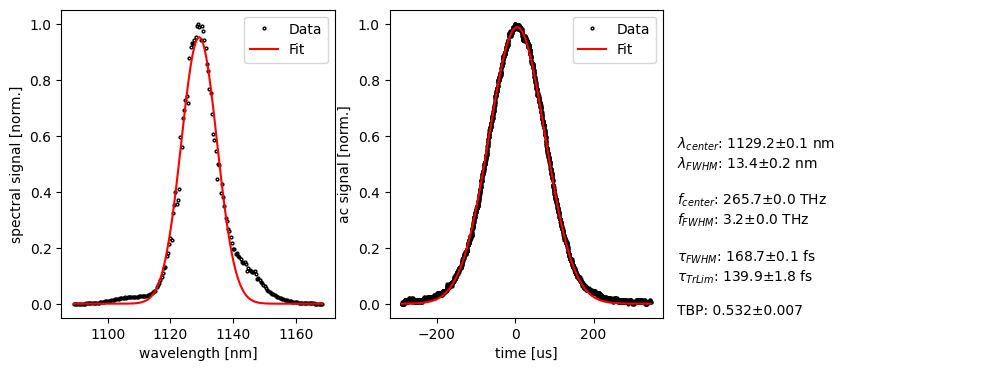

In [61]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].plot(wl_croped, osa_trace_croped, 'ko', label="Data", mfc = 'none', ms = 2)
ax[0].plot(wl_croped, gaussian(wl_croped, *popt_osa), 'r-', label="Fit")
ax[0].set_xlabel("wavelength [nm]")
ax[0].set_ylabel("spectral signal [norm.]")
ax[0].legend()
ax[1].plot(time, dso_trace, 'ko', label="Data", mfc = 'none', ms = 2)
ax[1].plot(time, gaussian(time, *popt_dso), 'r-', label="Fit")
ax[1].set_xlabel("time [us]")
ax[1].set_ylabel("ac signal [norm.]")
ax[1].legend()
ax[2].axis('off')
ax[2].text(-0.15, 0.0, f"$\\lambda_{{center}}$: {mu_osa_fit:.1f}±{sig_mu_osa_fit:.1f} nm\n$\\lambda_{{FWHM}}$: {fwhm_osa_fit:.1f}±{sig_fwhm_osa_fit:.1f} nm\n\n$f_{{center}}$: {mu_osa_fit_freq:.1f}±{sig_mu_osa_fit_freq:.1f} THz\n$f_{{FWHM}}$: {fwhm_osa_fit_freq:.1f}±{sig_fwhm_osa_fit_freq:.1f} THz\n\n$\\tau_{{FWHM}}$: {fwhm_dso_fit:.1f}±{sig_fwhm_dso_fit:.1f} fs\n$\\tau_{{TrLim}}$: {tr_lim_tau:.1f}±{sig_tr_lim_tau:.1f} fs\n\nTBP: {tbp:.3f}±{sig_tpb:.3f}",horizontalalignment='left', verticalalignment='bottom', fontsize=10)

plt.show()

In [6]:
#np.savetxt("spectra.txt", np.transpose([osa.wlArray, osa.trace]))
#np.savetxt("ac.txt", np.transpose([dso.time, dso.trace]))

In [7]:
popt_dso

array([ 0.98741746,  0.75935344, 26.5721593 ])